In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

In [2]:
from scipy.optimize import minimize 

#### Minimize f(x) = (x-3)^2

In [13]:
def f(x):
    return (x-3)**2


res = minimize(f, 2)

In [14]:
res

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 5.551437397369767e-17
        x: [ 3.000e+00]
      nit: 2
      jac: [-4.325e-13]
 hess_inv: [[ 5.000e-01]]
     nfev: 6
     njev: 3

In [15]:
res.x

array([2.99999999])

#### minimize f(x,y) = (x-1)^2 + (y-2.5)^2 subject to

#                         x-2y+2>0
#                         -x-2y+6>0
#                         -x+2y+2>0
#                           x>0
#                            y>0

In [19]:
f = lambda x: (x[0]-1)**2+ (x[1]-2.5)**2
cons = ({"type": "ineq", "fun": lambda x: x[0]-2*x[1]+2},
        {"type": "ineq", "fun": lambda x: -x[0]-2*x[1]+6},
        {"type": "ineq", "fun": lambda x: -x[0]+2*x[1]+2,})
bnds = ((0, None), (0,None))
res = minimize(f, (2,0), bounds=bnds, constraints =cons)

In [20]:
res

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 0.8000000011920985
       x: [ 1.400e+00  1.700e+00]
     nit: 3
     jac: [ 8.000e-01 -1.600e+00]
    nfev: 10
    njev: 3

In [21]:
res.x

array([1.4, 1.7])

In [22]:
minimize?

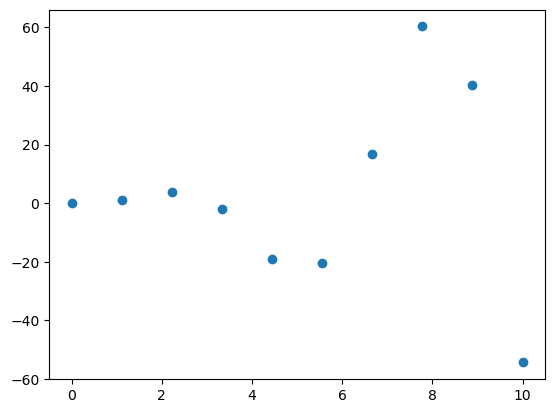

In [26]:
x =np.linspace(0,10,10)
y = x**2 * np.sin(x)
plt.scatter(x,y)

In [27]:
from scipy.interpolate import interp1d

In [32]:
f =interp1d(x, y, kind="cubic")
x_dense = np.linspace(0,10,100)
y_dense = f(x_dense)

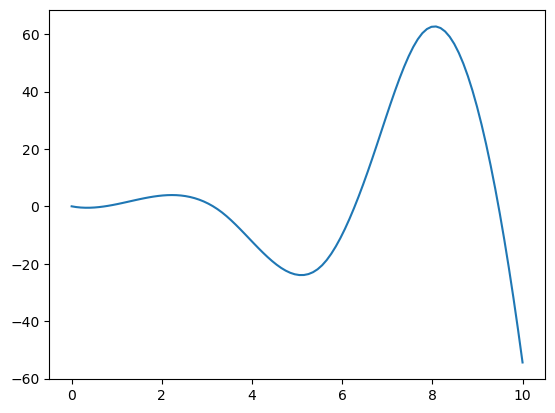

In [33]:
plt.plot(x_dense, y_dense)

In [34]:
x_data =np.linspace(0,10, 10)
y_data = 3*x_data**2 +2

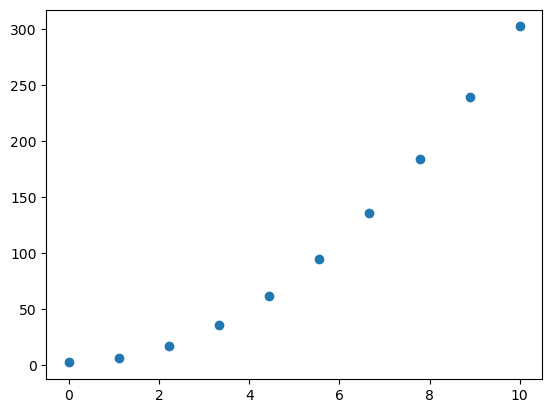

In [35]:
plt.scatter(x_data, y_data)

#### Want to fit the data  to the curve  y= ax ^2 +b . The main goal here is determine the value of a and b 

In [36]:
from scipy.optimize import curve_fit

def func(x, a, b):
    return a * x**2 + b
popt, pcov= curve_fit(func, x_data,y_data, p0=(1,1))

In [37]:
popt

array([3., 2.])